# P4: Two-Body Problem

mass ratios: 1:1, 1:2, 1:4, 1:16

eccentricities: 0, 0.25, 0.5, 0.75

Governing equations:
$$
x''=\frac{x}{(x^2+y^2)^{3/2}}
$$
$$
y''=\frac{y}{(x^2+y^2)^{3/2}}
$$

Initial conditions:
$$
x(0)=-1,\quad y(0)=0,\quad x'(0)=0,\quad y'(0)=\sqrt{1+\varepsilon}
$$

In [1]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# convert to 1st-order ODE system
def rhs(t, initial_state):
    x, y, vx, vy = initial_state
    r = (x**2 + y**2) ** (3/2)
    ax = -x / r
    ay = -y / r
    return vx, vy, ax, ay

# epsilon = 0.5
# ic = [-1, 0, 0, (1 + epsilon)**0.5]

# t_eval and ivp solver
# T = 2 * np.pi / (1 - epsilon) ** (3 / 2)
# t = np.linspace(0, T, 100)
# sol = solve_ivp(rhs, [0, T], ic, t_eval=t)

# compute r1(t) and r2(t)
def compute_pos(m1, m2, x, y):
    r1x = (m2 / (m1 + m2)) * x
    r1y = (m2 / (m1 + m2)) * y
    r2x = -(m1 / (m1 + m2)) * x
    r2y = -(m1 / (m1 + m2)) * y

    return (r1x, r1y), (r2x, r2y)

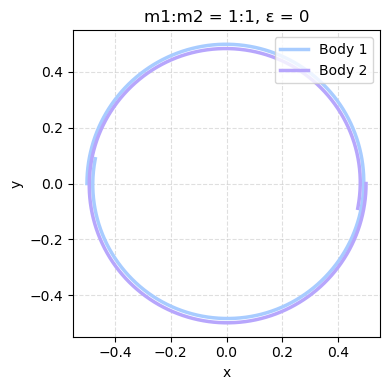

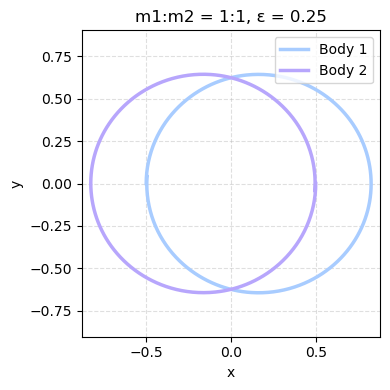

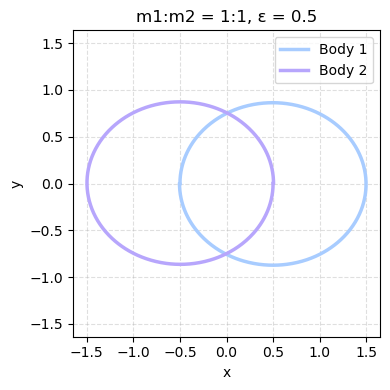

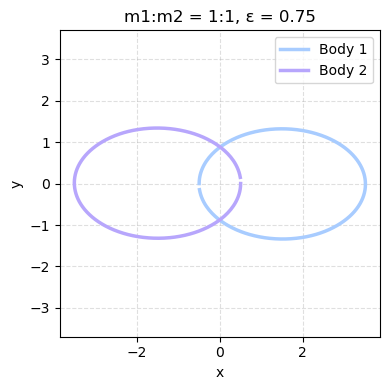

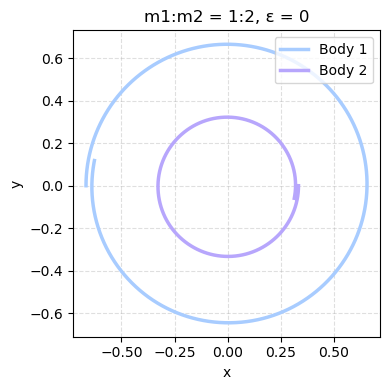

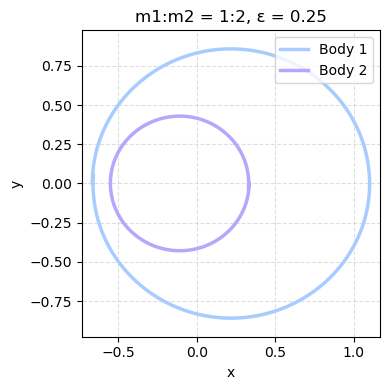

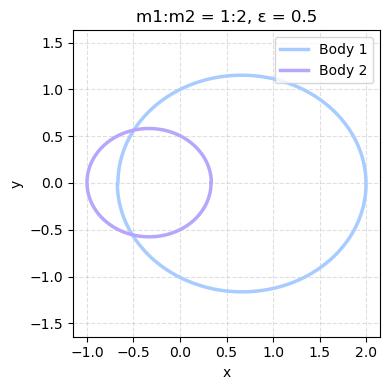

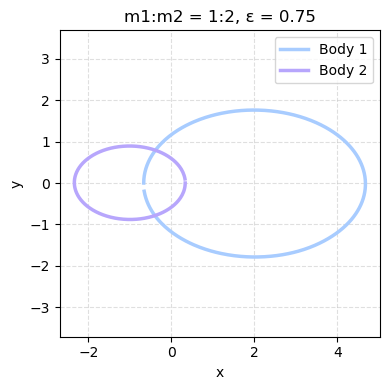

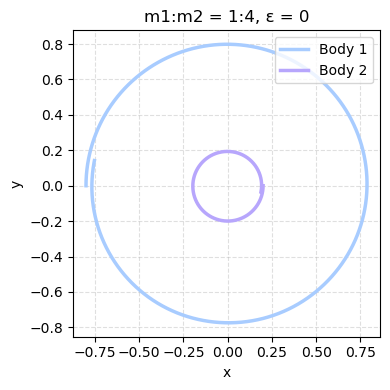

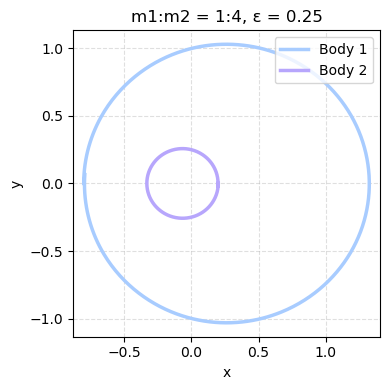

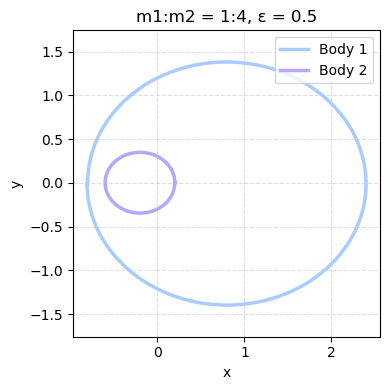

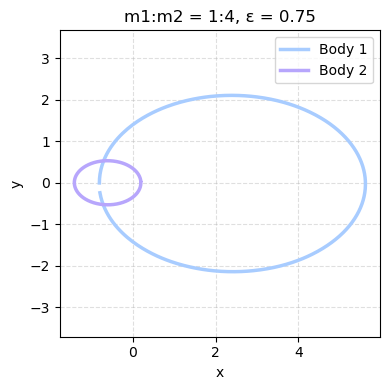

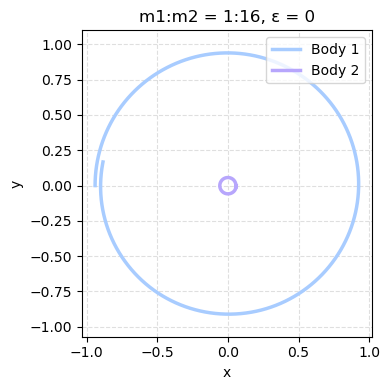

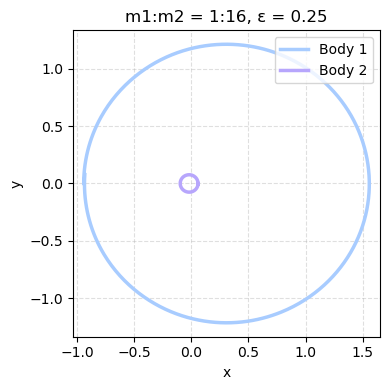

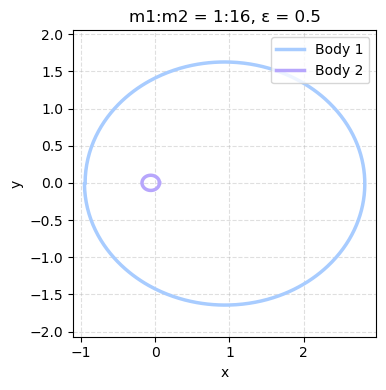

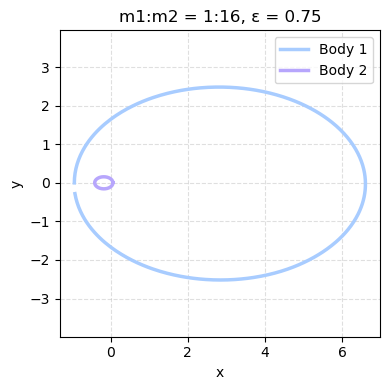

In [3]:
# loop over the 16 configs

m_ratios = [(1, 1), (1, 2), (1, 4), (1, 16)]
eps = [0, 0.25, 0.5, 0.75]

for m1, m2 in m_ratios:
    for epsilon in eps:
        ic = [-1, 0, 0, (1 + epsilon)**0.5]
        T = 2 * np.pi / (1 - epsilon) ** (3 / 2)
        t = np.linspace(0, T, 500)
        sol = solve_ivp(rhs, [0, T], ic, t_eval=t)

        # get r1(t) and r2(t) to store
        x = sol.y[0]
        y = sol.y[1]
        (r1x, r1y), (r2x, r2y) = compute_pos(m1, m2, x, y)
        
        # plot in this loop for convenience
        plt.figure(figsize=(4, 4))
        plt.plot(r1x, r1y, label='Body 1', color="#A8CCFF", linewidth=2.5)
        plt.plot(r2x, r2y, label='Body 2', color="#B7A6FC", linewidth=2.5)
        plt.title(f'm1:m2 = {m1}:{m2}, ε = {epsilon}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.axis('equal')
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.grid(alpha=0.4, linestyle='--')

        # save figures
        plt.savefig(f'{m1}_{m2}_{epsilon:0.2f}.png')
        plt.show()